# Part 1: Fairness Audits

## 1. Cohort Diagnostics and Demographic Distributions
Before generating counterfactuals, we inspect the preprocessed `mimic_features.parquet` dataset. This custom HTML dashboard verifies the data schema, confirms the presence of required identifiers, and visualizes the baseline demographic distributions (Age, Sex, Race, and Insurance) to ensure adequate representation for fairness auditing.

In [1]:
import os
import glob
import pandas as pd
from IPython.display import display, HTML

# Paths to inspect
dataset_dir = "/kaggle/input/datasets/luwammajor/clinical-pipeline-preprocessed"
parquet_path = os.path.join(dataset_dir, "mimic_features.parquet")

# Directory inspection
all_files = glob.glob(f"{dataset_dir}/*")
files_list = "".join([f"<li><code>{os.path.basename(f)}</code> ({os.path.getsize(f) / (1024 * 1024):.2f} MB)</li>" for f in all_files])

# Load dataset
df = pd.read_parquet(parquet_path)

# Columns and Types
schema_df = pd.DataFrame({"Column": df.columns, "Dtype": df.dtypes.astype(str)}).head(12)
schema_html = schema_df.to_html(index=False, classes="table table-sm table-striped")

# Demographic distributions side by side
demo_cols = [c for c in df.columns if any(k in c.lower() for k in ["race", "sex", "gender", "insur", "age", "ethnicity"])]
dist_tables_html = ""
for col in demo_cols[:4]:
    vc = df[col].value_counts(dropna=False).head(5).reset_index()
    vc.columns = [col, "Count"]
    dist_tables_html += f"""
    <div style="flex: 1; min-width: 180px; margin: 4px; padding: 8px; border: 1px solid rgba(128, 128, 128, 0.3); border-radius: 4px; background-color: transparent;">
        <h6 style="margin: 0 0 6px 0; font-weight: 600; color: inherit;">{col}</h6>
        {vc.to_html(index=False, classes="table table-sm")}
    </div>
    """

# Identifier / text columns check
id_text_cols = [c for c in df.columns if any(k in c.lower() for k in ["id", "text", "note", "section"])]
id_text_html = "".join([f"<span style='background-color: rgba(26, 115, 232, 0.15); color: #4285f4; padding: 2px 6px; margin: 2px; border-radius: 3px; display: inline-block;'>{c}</span>" for c in id_text_cols])

# diagnostic dashboard
dashboard_html = f"""
<div style="font-family: system-ui, -apple-system, sans-serif; font-size: 13px; line-height: 1.4; color: inherit; background-color: transparent;">
    <div style="display: flex; flex-wrap: wrap; gap: 12px; margin-bottom: 12px;">
        
        <!-- Left Panel: Directory & Metadata -->
        <div style="flex: 1; min-width: 280px; padding: 12px; border: 1px solid rgba(128, 128, 128, 0.3); border-radius: 6px; background-color: transparent;">
            <h5 style="margin-top: 0; color: inherit; border-bottom: 2px solid rgba(59, 130, 246, 0.6); padding-bottom: 4px;">1. Directory & File Info</h5>
            <p style="margin: 4px 0;"><strong>Dataset Shape:</strong> {df.shape[0]:,} rows &times; {df.shape[1]} cols</p>
            <p style="margin: 4px 0;"><strong>Files in Directory:</strong></p>
            <ul style="padding-left: 18px; margin: 4px 0;">{files_list}</ul>
            <p style="margin: 8px 0 4px 0;"><strong>ID / Text Columns Found:</strong></p>
            <div>{id_text_html}</div>
        </div>

        <!-- Right Panel: First 12 Schema Fields -->
        <div style="flex: 1.2; min-width: 320px; padding: 12px; border: 1px solid rgba(128, 128, 128, 0.3); border-radius: 6px; background-color: transparent;">
            <h5 style="margin-top: 0; color: inherit; border-bottom: 2px solid rgba(16, 185, 129, 0.6); padding-bottom: 4px;">2. Schema Overview (Preview)</h5>
            <div style="max-height: 200px; overflow-y: auto;">
                {schema_html}
            </div>
        </div>
    </div>

    <!-- Bottom Panel: Demographic Distributions Side-by-Side -->
    <div style="padding: 12px; border: 1px solid rgba(128, 128, 128, 0.3); border-radius: 6px; background-color: transparent; margin-bottom: 12px;">
        <h5 style="margin-top: 0; color: inherit; border-bottom: 2px solid rgba(139, 92, 246, 0.6); padding-bottom: 4px;">3. Demographic Distributions</h5>
        <div style="display: flex; flex-wrap: wrap; gap: 8px;">
            {dist_tables_html}
        </div>
    </div>
</div>
"""

display(HTML(dashboard_html))

# 6. Sample Transposed Row
print("=== 4. SAMPLE RECORD (FIRST ROW TRANSPOSED) ===")
display(df.head(1).T)

Column,Dtype
subject_id,int64
hadm_id,int64
admittime,datetime64[ns]
dischtime,datetime64[ns]
age,int64
sex,object
race_clean,object
insurance_clean,object
admission_type,object
los_days,float64


=== 4. SAMPLE RECORD (FIRST ROW TRANSPOSED) ===


,0
subject_id,10000032
hadm_id,22595853
admittime,2180-05-06 22:23:00
dischtime,2180-05-07 17:15:00
age,52
sex,Female
race_clean,White
insurance_clean,Medicaid
admission_type,URGENT
los_days,0.786111


## 2. Data Integration and Perturbation Maps
We load the raw clinical discharge summaries and join them with the demographic features (Race and Sex) using `hadm_id`. We also define the counterfactual transformation dictionaries (`RACE_MAP` and `SEX_MAP`), which specify how factual demographic markers (e.g., "african american", "male") will be swapped with their counterfactual equivalents (e.g., "white", "female").

In [2]:
import os
import re
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util

# File paths
features_path = "/kaggle/input/datasets/luwammajor/clinical-pipeline-preprocessed/mimic_features.parquet"
notes_path = "/kaggle/input/datasets/luwammajor/mimic-iv-notes/discharge.csv"

# Load tabular demographic features
print("Loading demographic features...")
features_df = pd.read_parquet(features_path)

# Load text notes (only reading required columns to conserve RAM)
print("Loading clinical discharge summaries...")
notes_df = pd.read_csv(notes_path, usecols=["hadm_id", "text"])

# Ensure ID types match and merge
features_df["hadm_id"] = features_df["hadm_id"].astype(int)
notes_df["hadm_id"] = notes_df["hadm_id"].astype(int)

print("Merging tabular features with clinical notes...")
merged_df = pd.merge(
    notes_df,
    features_df[["hadm_id", "race_clean", "sex", "race_x_sex"]],
    on="hadm_id",
    how="inner"
)
print(f"Merge successful: {len(merged_df):,} matched clinical encounters.")

# Demographic perturbation maps
RACE_MAP = {
    "african american": "white",
    "black": "white",
    "caucasian": "black",
    "white": "black",
    "hispanic": "white",
    "latino": "white",
    "asian": "white"
}

SEX_MAP = {
    "male": "female",
    "female": "male",
    "man": "woman",
    "woman": "man"
}

Loading demographic features...
Loading clinical discharge summaries...
Merging tabular features with clinical notes...
Merge successful: 293,760 matched clinical encounters.


## 3. Counterfactual Generation 
This function applies regex-bound string substitutions to the clinical text[. By searching for exact word boundaries (`\b`), it safely swaps demographic keywords without unintentionally altering sub-strings inside other medical terms.

In [4]:
def perturb_demographics(text: str, target_axis: str) -> str:
    """
    Applies regex-bound string substitution to swap demographic markers.
    """
    if pd.isna(text):
        return str(text)
    
    perturbed = str(text).lower()
    mapping = RACE_MAP if target_axis == "race" else SEX_MAP
    
    for factual, counterfactual in mapping.items():
        pattern = re.compile(rf"\b{re.escape(factual)}\b")
        perturbed = pattern.sub(counterfactual, perturbed)
        
    return perturbed

## 4. Full-Cohort Counterfactual Transformation
We apply the perturbation engine across the entire cohort, generating two new parallel text columns: `text_cf_race` and `text_cf_sex`. These represent alternative realities where the patient's demographics differ, but their clinical presentation remains identical.

In [5]:
# Apply regex to the ENTIRE dataset
print("Generating counterfactual notes for the entire dataset")
merged_df["text_cf_race"] = merged_df["text"].apply(lambda x: perturb_demographics(x, "race"))
merged_df["text_cf_sex"] = merged_df["text"].apply(lambda x: perturb_demographics(x, "sex"))
print(f"Successfully generated counterfactuals for {len(merged_df):,} records.")

Generating counterfactual notes for the entire dataset
Successfully generated counterfactuals for 293,760 records.


## 5. Semantic Preservation Check
To ensure the perturbation step did not accidentally destroy the clinical meaning of the notes, we validate a 2,000-record sample using Sentence-BERT (`all-MiniLM-L6-v2`) We compute the cosine similarity between the factual and counterfactual embeddings. A high similarity score proves the text's semantic integrity remains intact.

In [6]:
# STATISTICAL VALIDATION: Run SBERT only on a 2,000-record subset
print("\nSampling 2,000 records for SBERT validation...")
validation_sample = merged_df.sample(n=2000, random_state=42).copy()

print("Loading SBERT model: all-MiniLM-L6-v2...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Computing factual embeddings for the sample...")
factual_emb = model.encode(validation_sample["text"].tolist(), convert_to_tensor=True, show_progress_bar=True)

for cf_col in ["text_cf_race", "text_cf_sex"]:
    print(f"Validating semantic preservation for {cf_col}...")
    cf_emb = model.encode(validation_sample[cf_col].tolist(), convert_to_tensor=True, show_progress_bar=True)
    scores = util.cos_sim(factual_emb, cf_emb).diagonal()
    validation_sample[f"similarity_{cf_col}"] = scores.cpu().numpy()

print("\n=== Semantic Similarity Validation Summary (n=2000) ===")
display(validation_sample[["similarity_text_cf_race", "similarity_text_cf_sex"]].describe())


Sampling 2,000 records for SBERT validation...
Loading SBERT model: all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Validating semantic preservation for text_cf_sex...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]


=== Semantic Similarity Validation Summary (n=2000) ===


,similarity_text_cf_race,similarity_text_cf_sex
count,2000.000000,2000.000000
mean,0.999921,0.999701
std,0.000781,0.000873
min,0.982298,0.988582
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000001,1.000001


## 6. Semantic Similarity Distribution
This Kernel Density Estimation (KDE) plot visualizes the SBERT cosine similarity scores for both race and sex counterfactuals. We plot this against a strict validity threshold (0.95) to visually confirm that the perturbations are semantically safe.

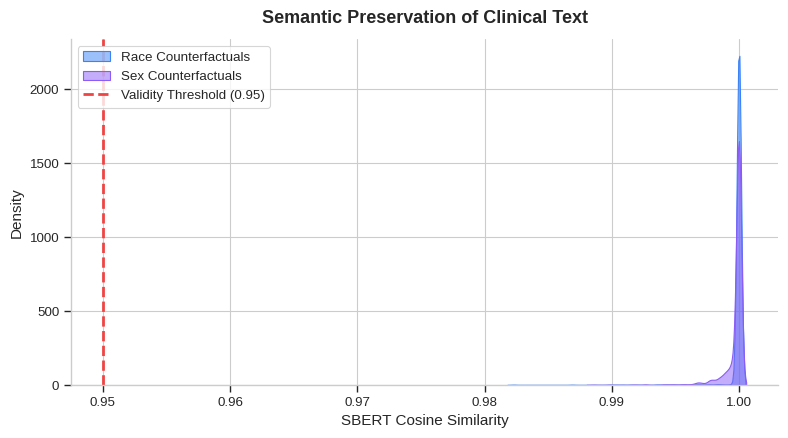

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.1)

def plot_semantic_preservation(df):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    # Plot KDEs for the distributions
    sns.kdeplot(data=df, x="similarity_text_cf_race", fill=True, label="Race Counterfactuals", color="#3b82f6", alpha=0.5, ax=ax)
    sns.kdeplot(data=df, x="similarity_text_cf_sex", fill=True, label="Sex Counterfactuals", color="#8b5cf6", alpha=0.5, ax=ax)
    
    # Add the validation threshold line
    ax.axvline(x=0.95, color='#ef4444', linestyle='--', linewidth=2, label='Validity Threshold (0.95)')
    
    # Formatting
    ax.set_title("Semantic Preservation of Clinical Text", fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("SBERT Cosine Similarity", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(loc='upper left', frameon=True)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_semantic_preservation(validation_sample)

## 7. Primary Cohort Isolation
To ensure a mathematically valid comparison, we must conduct our fairness audit on the exact same patient encounters processed in Stage 1. We load the preserved cohort identifiers from the master extraction notebook and filter our massive preprocessed dataset down to this specific 4,000-record primary cohort.

In [18]:
import os
import pandas as pd

# Dynamically search Kaggle's input directory for the exported IDs
input_dir = "/kaggle/input"
target_file = "cohort_4000_ids.parquet"
exact_path = None

for root, dirs, files in os.walk(input_dir):
    if target_file in files:
        exact_path = os.path.join(root, target_file)
        break

if exact_path:
    print(f"File found at: {exact_path}")
    ids_df = pd.read_parquet(exact_path)
    cohort_ids = ids_df["hadm_id"].tolist()
    
    # Filter the massive dataset down to the  specific 4,000 patients
    factual_4000 = merged_df[merged_df["hadm_id"].isin(cohort_ids)].copy()
    print(f"Isolated primary cohort: {len(factual_4000)} records.")
else:
    print(f"ERROR: {target_file} not found.")
    print("Save Version' in the LLM Notebook and attached via 'Add Data'.")

Success! File found at: /kaggle/input/datasets/luwammajor/shared-files/cohort_4000_ids.parquet
Isolated primary cohort: 4000 records.


## 8. Stratified Audit Sampling
Processing the full counterfactual dataset is computationally prohibitive and unnecessary for a robust statistical audit. We draw a 10% representative subset (400 records) stratified by the intersection of race and sex. This ensures that minority demographics remain proportionally represented in the fairness evaluation.

In [15]:
# Draw a 400-note stratified audit sample
# We stratify on race_x_sex to ensure minority groups are represented in the audit
sample_per_stratum = max(1, 400 // factual_4000["race_x_sex"].nunique())

audit_sample_400 = (
    factual_4000.groupby("race_x_sex", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), sample_per_stratum), random_state=42))
)

# Fill remainder randomly if integer rounding leaves us slightly under 400
if len(audit_sample_400) < 400:
    remainder_needed = 400 - len(audit_sample_400)
    remaining_pool = factual_4000[~factual_4000["hadm_id"].isin(audit_sample_400["hadm_id"])]
    extra_samples = remaining_pool.sample(n=remainder_needed, random_state=42)
    audit_sample_400 = pd.concat([audit_sample_400, extra_samples])

print(f"Stratified audit sample selected: {len(audit_sample_400)} records.")

Stratified audit sample selected: 400 records.


/tmp/ipykernel_58/2251091127.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), sample_per_stratum), random_state=42))


## 9. Formatting and Exporting LLM Inputs
To utilize our master inference notebook without altering its architecture, the counterfactual data must perfectly match the schema expected by the LLM. We isolate the counterfactual text columns, rename them to the standard `text` format, and export them as Parquet files ready for Stage 2 inference.

In [19]:
# Format and export the Race Counterfactuals for the LLM
cf_race = audit_sample_400[["hadm_id", "text_cf_race"]].copy()
cf_race = cf_race.rename(columns={"text_cf_race": "text"})
cf_race.to_parquet("/kaggle/working/stage2_cf_race_todo.parquet", index=False)

# Format and export the Sex Counterfactuals for the LLM
cf_sex = audit_sample_400[["hadm_id", "text_cf_sex"]].copy()
cf_sex = cf_sex.rename(columns={"text_cf_sex": "text"})
cf_sex.to_parquet("/kaggle/working/stage2_cf_sex_todo.parquet", index=False)

print("Export complete. Counterfactual files are ready for Notebook 1.")

Export complete. Counterfactual files are ready for Notebook 1.


## 10. Bias Migration Divergence Function
This function visualizes the core metric of our audit: $\Delta f(x)$. It plots the distribution of the difference between factual and counterfactual risk scores. In a perfectly fair system, this distribution will center exactly on zero.

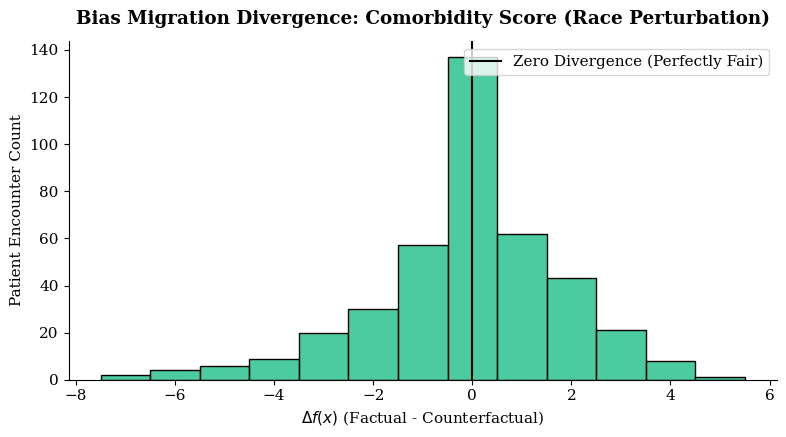

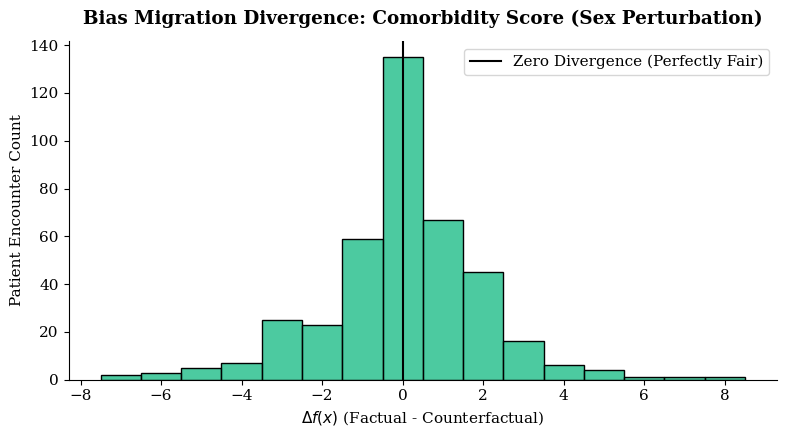

Counterfactual divergence figures saved to: /kaggle/working/figures


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Apply academic font settings for LaTeX
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

fig_dir = "/kaggle/working/figures"
os.makedirs(fig_dir, exist_ok=True)

# Load factual and counterfactual extraction results
factual_df = pd.read_parquet("/kaggle/input/datasets/luwammajor/gt-llm-eval/stage1_llama_extraction.parquet")
cf_race_df = pd.read_parquet("/kaggle/input/datasets/luwammajor/counterfactuals-output/stage2_cf_race_output.parquet")
cf_sex_df = pd.read_parquet("/kaggle/input/datasets/luwammajor/counterfactuals-output/stage2_cf_sex_output.parquet")

# Isolate the target metric and rename columns for clean merging
metric_col = "comorbidity_burden_score"

factual_sub = factual_df[["hadm_id", metric_col]].rename(columns={metric_col: f"factual_{metric_col}"})
cf_race_sub = cf_race_df[["hadm_id", metric_col]].rename(columns={metric_col: f"cf_race_{metric_col}"})
cf_sex_sub = cf_sex_df[["hadm_id", metric_col]].rename(columns={metric_col: f"cf_sex_{metric_col}"})

# Merge into a single evaluation dataframe
merged_cf = factual_sub.merge(cf_race_sub, on="hadm_id", how="inner").merge(cf_sex_sub, on="hadm_id", how="inner")

def plot_bias_divergence(df, cf_axis, metric_col, fig_name):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    # Calculate divergence: Factual Score - Counterfactual Score
    divergence = df[f"factual_{metric_col}"] - df[f"cf_{cf_axis}_{metric_col}"]
    
    # Plot the histogram of differences
    sns.histplot(divergence, bins=15, kde=False, color="#10b981", ax=ax, discrete=True)
    
    # Add a zero line representing perfect fairness
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, label='Zero Divergence (Perfectly Fair)')
    
    ax.set_title(f"Bias Migration Divergence: Comorbidity Score ({cf_axis.title()} Perturbation)", fontweight='bold', pad=12)
    ax.set_xlabel("$\\Delta f(x)$ (Factual - Counterfactual)")
    ax.set_ylabel("Patient Encounter Count")
    ax.legend(loc='upper right', frameon=True)
    
    sns.despine()
    plt.tight_layout()
    
    fig_path = f"{fig_dir}/{fig_name}.pdf"
    plt.savefig(fig_path, bbox_inches="tight", format="pdf")
    plt.show()
    plt.close(fig)

# Generate and save plots
plot_bias_divergence(merged_cf, cf_axis="race", metric_col=metric_col, fig_name="stage1_cf_divergence_race")
plot_bias_divergence(merged_cf, cf_axis="sex", metric_col=metric_col, fig_name="stage1_cf_divergence_sex")

print(f"Counterfactual divergence figures saved to: {fig_dir}")

# Part 2: Human-in-the-Loop Validation & Reliability Metrics

This analytical section evaluates the alignment between the human ground-truth annotations and the LLM extractions. 

To prove the extraction pipeline is scientifically reliable, we compute two core statistical measures:
* **Cohen's Kappa ($\kappa$):** Calculates inter-rater reliability for ordinal variables like the comorbidity burden score, applying quadratic weighting to account for the magnitude of disagreement.
* **Precision and Recall:** Quantifies exact match performance and error rates for categorical Social Determinants of Health (SDOH) flags against human-verified notes.

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix, mean_absolute_error

# Load manual annotations and LLM extractions
human_df = pd.read_csv("/kaggle/input/datasets/luwammajor/gt-llm-eval/Manual_Annotation.csv")
llm_df = pd.read_parquet("/kaggle/input/datasets/luwammajor/gt-llm-eval/stage1_llama_extraction.parquet")

# Filter completed annotations and merge on hadm_id
human_df = human_df.dropna(subset=["human_comorbidity_score"]).copy()
eval_df = human_df.merge(llm_df, on="hadm_id", how="inner")

print(f"Evaluating Inter-Rater Reliability on {len(eval_df)} human-annotated records...\n")

# Comorbidity Burden Score (Ordinal Data -> Quadratic Weighted Kappa)
kappa_score = cohen_kappa_score(
    eval_df["human_comorbidity_score"].astype(int), 
    eval_df["comorbidity_burden_score"].astype(int), 
    weights="quadratic"
)
print(f"Quadratic Weighted Kappa (Comorbidity Score): {kappa_score:.3f}")

#  SDOH Flags (Binary Data -> Exact Match Rate & Specificity)
flag_target = "substance_use"
eval_df[f"human_sdoh_{flag_target}"] = eval_df["human_sdoh_flags"].astype(str).str.contains(flag_target).astype(int)

exact_match = accuracy_score(
    eval_df[f"human_sdoh_{flag_target}"], 
    eval_df[f"sdoh_{flag_target}"]
)
print(f"SDOH '{flag_target.replace('_', ' ').title()}' Exact Match Rate: {exact_match * 100:.1f}%")

tn, fp, fn, tp = confusion_matrix(
    eval_df[f"human_sdoh_{flag_target}"], 
    eval_df[f"sdoh_{flag_target}"]
).ravel()

if (tn + fp) > 0:
    specificity = tn / (tn + fp)
    print(f"Specificity (True Negative Rate): {specificity * 100:.1f}%")
else:
    print("Specificity: No negative cases to evaluate.")

# Psychiatric Complexity (Categorical > Exact Match Rate)
psych_accuracy = accuracy_score(
    eval_df["human_psychiatric_complexity"].str.strip().str.lower(), 
    eval_df["psychiatric_complexity"].str.strip().str.lower()
)
print(f"Psychiatric Complexity Exact Match Rate: {psych_accuracy * 100:.1f}%")

# 5. Discharge Risk Indicator Count (Count -ean Absolute Error)
eval_df["human_indicator_count"] = eval_df["human_discharge_risk_indicators"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) and str(x).strip() != "" else 0
)
eval_df["llm_indicator_count"] = eval_df["discharge_risk_indicators_text"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) and str(x).strip() != "" else 0
)

mae_count = mean_absolute_error(eval_df["human_indicator_count"], eval_df["llm_indicator_count"])
print(f"Discharge Indicator Count MAE: {mae_count:.2f} (lower is better)")

Evaluating Inter-Rater Reliability on 41 human-annotated records...

Quadratic Weighted Kappa (Comorbidity Score): 0.766
SDOH 'Substance Use' Exact Match Rate: 92.7%
Specificity (True Negative Rate): 97.4%
Psychiatric Complexity Exact Match Rate: 75.6%
Discharge Indicator Count MAE: 1.27 (lower is better)
